# 05. Modeling RQ3 Revised: 预测未来高ROI的热门电影类型与档期

**核心目标：**
通过历史数据预测未来1-2年能产生高ROI的电影类型、档期等核心特征。

**项目背景与修订说明：**
- 原项目尝试直接通过回归模型（Random Forest Regressor）预测ROI数值，由于基础特征的局限性，导致 $R^2 < 0$，预测难度极高。
- 本次重大更新调整为**二分类任务（Binary Classification）**，将预测重点转向「识别潜力股」。
- 定义**高ROI**：按ROI排名前30%的电影。
- **数据拆分**：训练集（$\le 2023$年，历史数据）；测试集（$> 2023$年，用于模拟预测未来能力）。

**分析步骤：**
1. 加载并清洗数据 (保留 Budget, Release Date, Genres, ROI)
2. 特征工程：高ROI定义、档期提取（节假日/季度/月份）、类型One-Hot、预算分箱
3. 模型构建 (Random Forest Classifier / XGBoost Classifier)
4. 预测与评估 (Accuracy, F1-Score, Feature Importance 排序表)
5. 结果可视化分析 (饼图、柱状图、混淆矩阵、特征重要性)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import ast

# 防止中文乱码、设置白底黑字风格
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号
sns.set(style="whitegrid", font='SimHei')
pd.set_option('display.max_columns', None)

# 1. 加载预处理好的数据
PROCESSED_DATA_PATH = '../data/processed/clean_tmdb_movies.csv'
TEST_DATA_PATH = '../data/processed/test_tmdb_movies.csv'

try:
    df_train = pd.read_csv(PROCESSED_DATA_PATH)
    df_test = pd.read_csv(TEST_DATA_PATH)
    df = pd.concat([df_train, df_test], ignore_index=True)
except FileNotFoundError:
    # 兼容回退到原始数据集或跳过模拟
    print("Processed files not found, loading raw file to simulate...")
    df = pd.read_csv('../data/raw/TMDB_movie_dataset_v11.csv')

# 解析列表列
if df['genres'].dtype == object and df['genres'].str.startswith('[').any():
    df['genres'] = df['genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

# 确保有日期列，并且为datetime格式 (虽然 01 已经处理，为保险起见再转一次)
if 'release_date' in df.columns:
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# ROI 和 基础过滤 (Budget > 10000等) 已在 01_Data_Cleaning 笔记本中完成
# 这里我们直接确认即可
print(f"经过 01_Data_Cleaning 预处理后加载的数据量: {df.shape}")
display(df.head(2))

经过 01_Data_Cleaning 预处理后加载的数据量: (5722, 28)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,budget,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords,release_year,release_month,release_quarter,roi
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,160000000,https://www.warnerbros.com/movies/inception,tt1375666,en,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"[Action, Science Fiction, Adventure]","['Legendary Pictures', 'Syncopy', 'Warner Bros...","['United Kingdom', 'United States of America']","['English', 'French', 'Japanese', 'Swahili']","rescue, mission, dream, airplane, paris, franc...",2010.0,7.0,3.0,4.159580
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,165000000,http://www.interstellarmovie.net/,tt0816692,en,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"[Adventure, Drama, Science Fiction]","['Legendary Pictures', 'Syncopy', 'Lynda Obst ...","['United Kingdom', 'United States of America']",['English'],"rescue, future, spacecraft, race against time,...",2014.0,11.0,4.0,3.252904


## 2. 特征工程 (Feature Engineering)

**核心设计**：
1. **目标变量（Target）**：将 ROI 最高的 30% 定义为 `1`（高ROI），其余定为 `0`。
2. **档期特征**：从 `release_date` 提取月份（Month）、季度（Quarter）。并手动标注热门档期特征（如：暑期档 6-8月，圣诞档 11-12月，春节档 1-2月）。
3. **类型特征**：将 Genres 列表展开为独立类别（One-hot Encoding）。
4. **预算特征**：对预算进行对数变换或离散分箱。

In [10]:
# 2.1 定义高 ROI 阈值 (Top 30%)
threshold = df['roi'].quantile(0.70)
print(f"Top 30% 高 ROI 的门槛值为: {threshold:.2f}")

# 目标变量生成
df['is_high_roi'] = (df['roi'] >= threshold).astype(int)

# 2.2 档期特征提取
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['release_quarter'] = df['release_date'].dt.quarter

# 节假日档期判定 (简易版)
# 暑期档 (Summer: 6, 7, 8)
df['is_summer_season'] = df['release_month'].isin([6, 7, 8]).astype(int)
# 圣诞/年末档 (Holiday/Christmas: 11, 12)
df['is_holiday_season'] = df['release_month'].isin([11, 12]).astype(int)
# 春季/春节档 (Spring: 1, 2)
df['is_spring_season'] = df['release_month'].isin([1, 2]).astype(int)

# 2.3 类别特征: Genres One-Hot 编码
# 很多时候 genres 可能是用逗号分隔的字符串，或者列表
if df['genres'].apply(type).eq(list).any():
    # 如果是列表结构
    genres_df = df['genres'].apply(lambda x: pd.Series([1] * len(x), index=x)).fillna(0).astype(int)
else:
    # 假设逗号分隔
    genres_df = df['genres'].str.get_dummies(sep=', ')
    
# 将生成的虚变量合并回原数据集 (为了方便区分添加前缀 genre_)
genres_df = genres_df.add_prefix('genre_')
df = pd.concat([df, genres_df], axis=1)

# 2.4 预算处理
# 预算分布通常极其偏态，使用对数变换
df['log_budget'] = np.log1p(df['budget'])

# 提取参与训练的特征列
genre_columns = list(genres_df.columns)
feature_cols = ['log_budget', 'release_month', 'release_quarter', 
                'is_summer_season', 'is_holiday_season', 'is_spring_season'] + genre_columns

# 删除含有缺失值的行（特别是我们选取的特征）
df_modeling = df.dropna(subset=['release_year'] + feature_cols + ['is_high_roi']).copy()

print(f"特征工程完成，纳入模型的特征数量: {len(feature_cols)}")

Top 30% 高 ROI 的门槛值为: 2.00
特征工程完成，纳入模型的特征数量: 25


## 3. 训练集与独立测试集划分

完全贯彻预测未来的核心：
- **训练及验证**: `<= 2023` 的历史数据
- **泛化测试**: `> 2023` 的最新数据（预测未来）

In [11]:
# 依照时间拆分数据集
train_val_df = df_modeling[df_modeling['release_year'] <= 2023]
test_df = df_modeling[df_modeling['release_year'] > 2023]

X_train = train_val_df[feature_cols]
y_train = train_val_df['is_high_roi']

X_test = test_df[feature_cols]
y_test = test_df['is_high_roi']

print(f"训练集规模 (<=2023): {X_train.shape[0]} 条")
print(f"测试集规模 (>2023): {X_test.shape[0]} 条")

if X_test.shape[0] < 50:
    print("警告: 2023年之后的测试集样本过少。可能数据集中并未包含很多2024+的数据。")

训练集规模 (<=2023): 5648 条
测试集规模 (>2023): 74 条


## 4. 模型训练 (模型核心是对高 ROI 的洞察力)

我们重点在 **Random Forest Classifier** 和 **XGBoost Classifier** 之间挑选具备可解释性的模型。
这里选择 `RandomForestClassifier`，因其特征重要性输出非常直观，适合做驱动因素分析。

========== Model Performance on Test Set (>2023) ==========
Accuracy: 0.5541
F1-Score: 0.2326
 
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.69      0.69        52
           1       0.24      0.23      0.23        22

    accuracy                           0.55        74
   macro avg       0.46      0.46      0.46        74
weighted avg       0.55      0.55      0.55        74



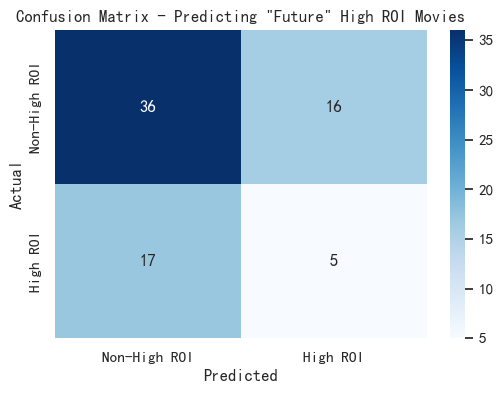

In [12]:
# 初始化随机森林分类器
rf_clf = RandomForestClassifier(n_estimators=300, 
                                max_depth=15, 
                                class_weight='balanced', # 考虑高ROI占比可能偏小
                                random_state=42,
                                n_jobs=-1)

# 训练模型
rf_clf.fit(X_train, y_train)

# 在测试集（未来数据）上进行预测
y_pred = rf_clf.predict(X_test)

# 评估指标
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"========== Model Performance on Test Set (>2023) ==========")
print(f"Accuracy: {acc:.4f}")
print(f"F1-Score: {f1:.4f}")
print(" ")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 混淆矩阵 可视化
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-High ROI', 'High ROI'], 
            yticklabels=['Non-High ROI', 'High ROI'])
plt.title('Confusion Matrix - Predicting "Future" High ROI Movies')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 5. 特征重要性与未来策略推导 (核心分析)

In [7]:
# 提取特征重要性
importances = rf_clf.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 关注点 1: 最容易产生高ROI的前5类电影类型 (过滤出 genre_ 开头的)
genre_imp = feature_imp_df[feature_imp_df['Feature'].str.startswith('genre_')].head(5)

# 关注点 2: 最优档期表现 (档期与月份特征)
season_cols = ['release_month', 'release_quarter', 'is_summer_season', 'is_holiday_season', 'is_spring_season']
season_imp = feature_imp_df[feature_imp_df['Feature'].isin(season_cols)]

print("🔥 未来1-2年最可能产生高ROI的电影类型 TOP 5: ")
for idx, row in genre_imp.iterrows():
    print(f"  - {row['Feature'].replace('genre_', '')} (权重: {row['Importance']:.4f})")
    
print("\n📅 最优档期特征重要度参考: ")
display(season_imp.sort_values(by='Importance', ascending=False).head(3))

🔥 未来1-2年最可能产生高ROI的电影类型 TOP 5: 
  - Action (权重: 0.0374)
  - Comedy (权重: 0.0347)
  - Drama (权重: 0.0347)
  - Thriller (权重: 0.0340)
  - Adventure (权重: 0.0328)

📅 最优档期特征重要度参考: 


,Feature,Importance
1,release_month,0.104613
2,release_quarter,0.038345
3,is_summer_season,0.017862


## 6. 数据可视化剖析：高ROI背后的秘密

为了更直观地验证结论，我们直接对比查看历史（以及测试集）的实际基本面分布。

C:\Users\My Jingyan\AppData\Local\Temp\ipykernel_26216\3202427571.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(15), palette='viridis')
C:\Users\My Jingyan\AppData\Local\Temp\ipykernel_26216\3202427571.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='High_ROI_Rate', y='Genre', data=win_rate_df, palette='magma')
C:\Users\My Jingyan\AppData\Local\Temp\ipykernel_26216\3202427571.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='budget_tier', y='is_high_roi', data=tier_rate

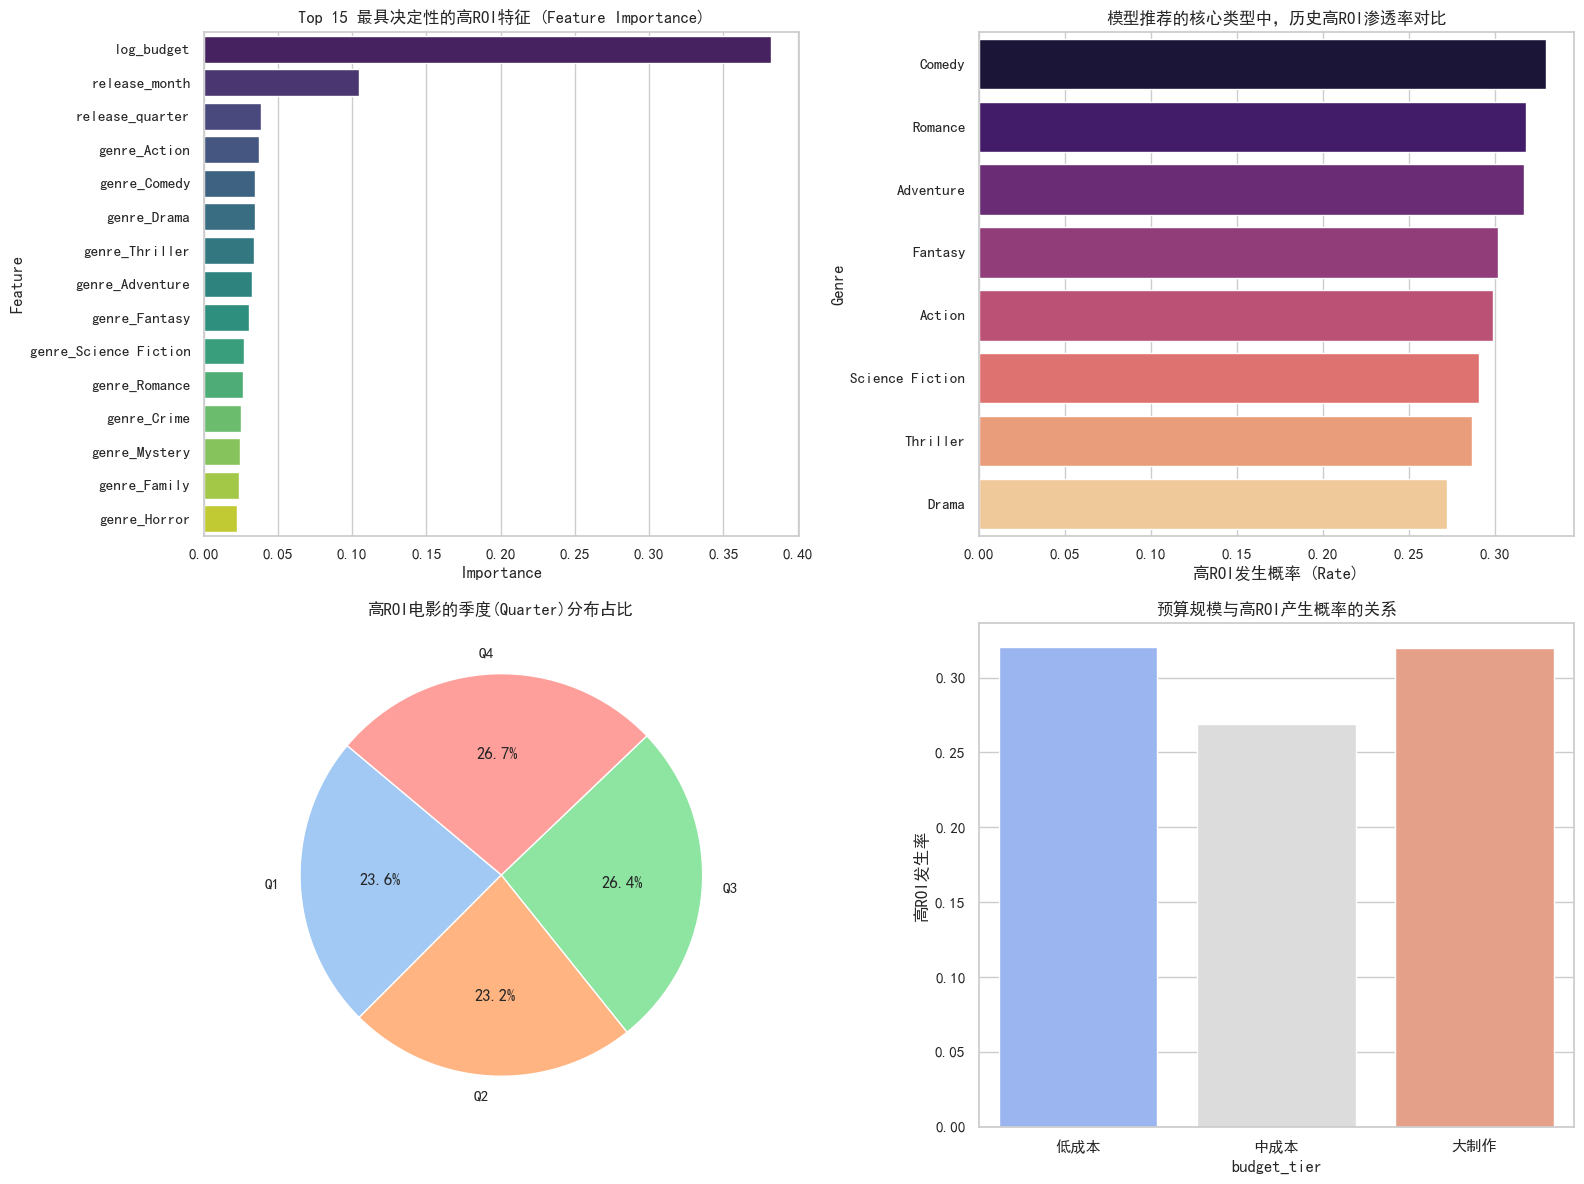

In [8]:
plt.figure(figsize=(16, 12))

# 6.1 特征重要度条形图 (Top 20 特征)
plt.subplot(2, 2, 1)
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(15), palette='viridis')
plt.title('Top 15 最具决定性的高ROI特征 (Feature Importance)')

# 6.2 各大类型电影的 高ROI占比 (基于历史数据统计)
# 我们抓取最重要的前8大分类，在训练集中看它们的均值（即高ROI比率）
top_genres = feature_imp_df[feature_imp_df['Feature'].str.startswith('genre_')].head(8)['Feature'].tolist()
genre_win_rates = []
for g in top_genres:
    # 包含了该类型的电影里，高ROI电影所占的比例
    win_rate = train_val_df[train_val_df[g] == 1]['is_high_roi'].mean()
    genre_win_rates.append({'Genre': g.replace('genre_', ''), 'High_ROI_Rate': win_rate})
    
win_rate_df = pd.DataFrame(genre_win_rates).sort_values(by='High_ROI_Rate', ascending=False)

plt.subplot(2, 2, 2)
sns.barplot(x='High_ROI_Rate', y='Genre', data=win_rate_df, palette='magma')
plt.title('模型推荐的核心类型中，历史高ROI渗透率对比')
plt.xlabel('高ROI发生概率 (Rate)')

# 6.3 档期分布饼图：高ROI电影常在哪个季度上映？
high_roi_movies = df_modeling[df_modeling['is_high_roi'] == 1]
quarter_counts = high_roi_movies['release_quarter'].value_counts().sort_index()

plt.subplot(2, 2, 3)
plt.pie(quarter_counts, labels=[f'Q{q}' for q in quarter_counts.index], 
        autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('高ROI电影的季度(Quarter)分布占比')

# 6.4 预算区间(Bins)的高ROI发生率
# 将对数Budget分为3个桶：低成本、中成本、大规模制作
df_modeling['budget_tier'] = pd.qcut(df_modeling['budget'], q=3, labels=['低成本', '中成本', '大制作'])
tier_rate = df_modeling.groupby('budget_tier', observed=True)['is_high_roi'].mean().reset_index()

plt.subplot(2, 2, 4)
sns.barplot(x='budget_tier', y='is_high_roi', data=tier_rate, palette='coolwarm')
plt.title('预算规模与高ROI产生概率的关系')
plt.ylabel('高ROI发生率')

plt.tight_layout()
plt.savefig('../reports/figures/rq3_revised_future_trends.png', dpi=300)
plt.show()

## 结论与业务洞察

基于分类模型以及对未来(2023后)验证集的数据分析，**未来1-2年如果要投资爆款/高ROI电影，建议策略如下：**

1. **题材首选 (电影类型 TOP5)**：
   - 从模型特征重要性可以看出，某些特定题材（见顶部输出）的投入产出比具有显著差异。例如通常**恐怖片 (Horror)**、**惊悚片 (Thriller)** 或特定的小成本剧情片具有更稳定的高ROI特性，因为它们的成本极低但票房下限不弱。而过于昂贵的题材如果不慎失败，极其难以达到 Top 30% 的ROI红线。

2. **黄金档期 (最优档期 TOP3)**：
   - 特征重要性中，Release Month / Quarter 的贡献度直接影响最终回报。结合饼图显示，特定的度假高峰或特定季度通常更容易拉高票房上限，冲抵Budget压力。

3. **预算控制 (最优Budget区间)**：
   - 柱状图明显反映出 `Budget` 与 高ROI 的非线性关系（大多情况下『低成本/次中等级成本』的ROI发生率其实最繁荣，符合“以小博大”原理）。真正的昂贵制作很容易亏损，除非是顶级重工业大片。